In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [18]:
class AgentState(TypedDict):
    value : list[int]
    name : str
    result: str
    message: str


In [19]:
from math import prod

def process_value(state: AgentState):
    """function handles multiple different inputs"""
    print(state)

    state["result"] = f"HI there {state["name"]}! your sum = {sum(state["value"])} and your multiplication {prod(state["value"])}"

    print(state)
    return state

def checking(state: AgentState):
    "this is a random agent for testing"
    print(state)

    state["message"] = f" {state["message"]}"
    print(state)
    return state




In [20]:
graph = StateGraph(AgentState)

graph.add_node("process" , process_value)
graph.add_node("checking", checking)

graph.set_entry_point("process")
graph.add_edge("process" , "checking")
graph.set_finish_point("checking")

app = graph.compile()

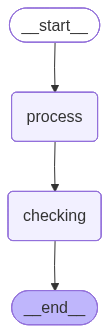

In [21]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [24]:
answer = app.invoke({
    "value": [1, 2, 3, 4],
    "name": "Junaid",
    "message": "Hello",
})

{'value': [1, 2, 3, 4], 'name': 'Junaid', 'message': 'Hello'}
{'value': [1, 2, 3, 4], 'name': 'Junaid', 'message': 'Hello', 'result': 'HI there Junaid! your sum = 10 and your multiplication 24'}
{'value': [1, 2, 3, 4], 'name': 'Junaid', 'result': 'HI there Junaid! your sum = 10 and your multiplication 24', 'message': 'Hello'}
{'value': [1, 2, 3, 4], 'name': 'Junaid', 'result': 'HI there Junaid! your sum = 10 and your multiplication 24', 'message': ' Hello'}


In [28]:
print(answer)
print(answer["result"])
print(answer["message"])

{'value': [1, 2, 3, 4], 'name': 'Junaid', 'result': 'HI there Junaid! your sum = 10 and your multiplication 24', 'message': ' Hello'}
HI there Junaid! your sum = 10 and your multiplication 24
 Hello
